# Dataset

## dataset calling

In [115]:
%matplotlib inline
import pandas as pd
df=pd.read_csv("final_dataset_std.csv", delimiter=';')
df.head()

,P_ac-0,P_ac-1,P_ac-2,P_ac-3,P_ac-4,P_ac-5,P_ac-6,P_ac-7,P_cu-0,P_cu-1,...,T_celCC-1,T_celCC-2,T_celCC-3,T_celCC-4,T_celCC-5,T_celCC-6,T_celCC-7,TLHC,DoW,WeH
0,1.483644,1.330373,1.177123,1.177087,2.861902,0.410917,0.104564,0.717323,-1.055378,-0.905744,...,1.135913,0.998844,0.724750,1.272878,1.341339,0.724663,0.313564,-0.307313,1,1
1,1.330427,1.483587,1.330334,1.177087,1.176840,2.861931,0.410944,0.104564,-0.905809,-1.055317,...,1.204436,1.135888,0.998839,0.724711,1.272820,1.341334,0.724681,-0.307313,1,1
2,1.330427,1.330373,1.483546,1.330296,1.176840,1.176859,2.861981,0.410944,-1.055378,-0.905744,...,1.341483,1.204411,1.135884,0.998794,0.724667,1.272815,1.341355,-0.352852,1,1
3,1.330427,1.330373,1.330334,1.483505,1.330028,1.176859,1.176893,2.861981,-0.905809,-1.055317,...,0.587727,1.341456,1.204406,1.135836,0.998744,0.724663,1.272836,-0.398391,1,1
4,1.330427,1.330373,1.330334,1.330296,1.483215,1.330047,1.176893,1.176893,-0.905809,-0.905744,...,0.930343,0.587709,1.341451,1.204357,1.135782,0.998739,0.724681,-0.352852,1,1


## feature selection(basic)

### feature engineering(advance , creating new more meaningful features from raw data )

#### seprating like features togather

In [116]:
ac_cols = df.filter(like="P_ac").columns# ac columns data
cu_cols = df.filter(like="P_cu").columns# cu columns data
cold_cols = df.filter(like="T_celCC").columns # temprature of celing data
print(ac_cols[:8],cu_cols[:8],cold_cols[:4])

Index(['P_ac-0', 'P_ac-1', 'P_ac-2', 'P_ac-3', 'P_ac-4', 'P_ac-5', 'P_ac-6',
       'P_ac-7'],
      dtype='object') Index(['P_cu-0', 'P_cu-1', 'P_cu-2', 'P_cu-3', 'P_cu-4', 'P_cu-5', 'P_cu-6',
       'P_cu-7'],
      dtype='object') Index(['T_celCC-0', 'T_celCC-1', 'T_celCC-2', 'T_celCC-3'], dtype='object')


In [117]:
df['total_ac_power']=df[ac_cols].sum(axis=1)
df['total_cu_power']=df[cu_cols].sum(axis=1)

In [118]:
df['avg_cold_cols_temp']=df[cold_cols].mean(axis=1)
df['min_cold_cols_temp']=df[cold_cols].min(axis=1)
df['max_cold_cols_temp']=df[cold_cols].max(axis=1)
df['std_cold_cols_temp']=df[cold_cols].std(axis=1)

In [119]:
df["thermal_load_ratio"] = df["total_cu_power"] / (df["total_ac_power"] + 1)
df["cu_ac_interaction"] = df["total_cu_power"] * df["total_ac_power"]


In [120]:
df["cooling_efficiency"] = df["total_ac_power"] / (df["avg_cold_cols_temp"] + 1)
df['heat_minus_cool'] = df['total_cu_power']- df['total_ac_power']


In [121]:
print(df.columns.values)

['P_ac-0' 'P_ac-1' 'P_ac-2' 'P_ac-3' 'P_ac-4' 'P_ac-5' 'P_ac-6' 'P_ac-7'
 'P_cu-0' 'P_cu-1' 'P_cu-2' 'P_cu-3' 'P_cu-4' 'P_cu-5' 'P_cu-6' 'P_cu-7'
 'T_out-0' 'T_out-1' 'T_out-2' 'T_out-3' 'T_out-4' 'T_out-5' 'T_out-6'
 'T_out-7' 'T_MEAS-0' 'T_MEAS-1' 'T_MEAS-2' 'T_MEAS-3' 'T_MEAS-4'
 'T_MEAS-5' 'T_MEAS-6' 'T_MEAS-7' 'T_celCC-0' 'T_celCC-1' 'T_celCC-2'
 'T_celCC-3' 'T_celCC-4' 'T_celCC-5' 'T_celCC-6' 'T_celCC-7' 'TLHC' 'DoW'
 'WeH' 'total_ac_power' 'total_cu_power' 'avg_cold_cols_temp'
 'min_cold_cols_temp' 'max_cold_cols_temp' 'std_cold_cols_temp'
 'thermal_load_ratio' 'cu_ac_interaction' 'cooling_efficiency'
 'heat_minus_cool']


In [122]:
x=df.drop('TLHC',axis=1)
y=df['TLHC']
print(x.info(),y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27013 entries, 0 to 27012
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   P_ac-0              27013 non-null  float64
 1   P_ac-1              27013 non-null  float64
 2   P_ac-2              27013 non-null  float64
 3   P_ac-3              27013 non-null  float64
 4   P_ac-4              27013 non-null  float64
 5   P_ac-5              27013 non-null  float64
 6   P_ac-6              27013 non-null  float64
 7   P_ac-7              27013 non-null  float64
 8   P_cu-0              27013 non-null  float64
 9   P_cu-1              27013 non-null  float64
 10  P_cu-2              27013 non-null  float64
 11  P_cu-3              27013 non-null  float64
 12  P_cu-4              27013 non-null  float64
 13  P_cu-5              27013 non-null  float64
 14  P_cu-6              27013 non-null  float64
 15  P_cu-7              27013 non-null  float64
 16  T_ou

## test train split

In [123]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)


In [124]:
print("TLHC min:", y.min())
print("TLHC max:", y.max())
print("TLHC mean:", y.mean())


TLHC min: -2.584251802962952
TLHC max: 1.7874707254069804
TLHC mean: -2.1265200223587957e-13


# linear regression

## training

In [125]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()


In [126]:
lr_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## linear regression prediction

### predict

In [127]:
y_lr_test_pred=lr_model.predict(x_test)
y_lr_train_pred=lr_model.predict(x_train)

### error computation

In [128]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

#test data eval
y_lr_test_mse=mean_squared_error(y_test,y_lr_test_pred)
y_lr_test_rmse=np.sqrt(y_lr_test_mse) # Correctly calculate RMSE
y_lr_test_mae=mean_absolute_error(y_test,y_lr_test_pred) # Correctly calculate MAE
y_lr_test_r2=r2_score(y_test,y_lr_test_pred)

#training data eval how well is model trained on traing dataset
y_lr_train_mse=mean_squared_error(y_train,y_lr_train_pred)
y_lr_train_rmse=np.sqrt(y_lr_train_mse) # Correctly calculate RMSE
y_lr_train_mae=mean_absolute_error(y_train,y_lr_train_pred) # Correctly calculate MAE
y_lr_train_r2=r2_score(y_train,y_lr_train_pred)

## evaluation on training

In [129]:


result_train = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [y_lr_train_rmse],
    "MAE": [y_lr_train_mae],
    "R2": [y_lr_train_r2]
})

print(result_train)


               Model      RMSE       MAE        R2
0  Linear Regression  0.405926  0.320942  0.835367


## test evaluatation

In [130]:
results = pd.DataFrame(columns=["Model", "RMSE", "MAE", "R2"])
results.loc[len(results)] = ["Linear Regression", y_lr_test_rmse,y_lr_test_mae,y_lr_test_r2]
results.head()

,Model,RMSE,MAE,R2
0,Linear Regression,0.405863,0.320934,0.834648


# random forest

## fine tunning random forest for no. of trees

In [131]:
'''from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200,300,400,500,600],
    "max_depth": [None,10,20,30,40],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}


rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

search.fit(x_train, y_train)

print("Best Parameters:", search.best_params_)'''


'from sklearn.ensemble import RandomForestRegressor\nfrom sklearn.model_selection import RandomizedSearchCV\n\nparam_dist = {\n    "n_estimators": [200,300,400,500,600],\n    "max_depth": [None,10,20,30,40],\n    "min_samples_split": [2,5,10],\n    "min_samples_leaf": [1,2,4]\n}\n\n\nrf = RandomForestRegressor(random_state=42)\n\nsearch = RandomizedSearchCV(\n    rf,\n    param_distributions=param_dist,\n    n_iter=30,\n    cv=5,\n    scoring="r2",\n    n_jobs=-1,\n    random_state=42\n)\n\nsearch.fit(x_train, y_train)\n\nprint("Best Parameters:", search.best_params_)'

## training ramdom forest for n=300

In [132]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [133]:
y_rf_test_pred=rf_model.predict(x_test)
y_rf_train_pred=rf_model.predict(x_train)

In [134]:
#test data eval
y_rf_test_mse=mean_squared_error(y_test,y_rf_test_pred)
y_rf_test_rmse=np.sqrt(y_rf_test_mse) # Correctly calculate RMSE
y_rf_test_mae=mean_absolute_error(y_test,y_rf_test_pred) # Correctly calculate MAE
y_rf_test_r2=r2_score(y_test,y_rf_test_pred)

#training data eval how well is model trained on traing dataset
y_rf_train_mse=mean_squared_error(y_train,y_rf_train_pred)
y_rf_train_rmse=np.sqrt(y_rf_train_mse) # Correctly calculate RMSE
y_rf_train_mae=mean_absolute_error(y_train,y_rf_train_pred) # Correctly calculate MAE
y_rf_train_r2=r2_score(y_train,y_rf_train_pred)

In [135]:

result_train_rf = pd.DataFrame({
    "Model": ["random forest"],
    "RMSE": [y_rf_train_rmse],
    "MAE": [y_rf_train_mae],
    "R2": [y_rf_train_r2]
})

print(result_train_rf)


           Model      RMSE       MAE        R2
0  random forest  0.062764  0.042721  0.996064


In [136]:

results.loc[len(results)] = ["random forest", y_rf_test_rmse,y_rf_test_mae,y_rf_test_r2]
results.head()

,Model,RMSE,MAE,R2
0,Linear Regression,0.405863,0.320934,0.834648
1,random forest,0.166563,0.114539,0.972151


# extra trees

In [137]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

et_model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [138]:
y_et_train_pred=et_model.predict(x_train)
y_et_test_pred=et_model.predict(x_test)

In [139]:
#test data eval
y_et_test_mse=mean_squared_error(y_test,y_et_test_pred)
y_et_test_rmse=np.sqrt(y_et_test_mse) # Correctly calculate RMSE
y_et_test_mae=mean_absolute_error(y_test,y_et_test_pred) # Correctly calculate MAE
y_et_test_r2=r2_score(y_test,y_et_test_pred)

#training data eval how well is model trained on traing dataset
y_et_train_mse=mean_squared_error(y_train,y_et_train_pred)
y_et_train_rmse=np.sqrt(y_et_train_mse) # Correctly calculate RMSE
y_et_train_mae=mean_absolute_error(y_train,y_et_train_pred) # Correctly calculate MAE
y_et_train_r2=r2_score(y_train,y_et_train_pred)

In [140]:
result_train_et = pd.DataFrame({
    "Model": ["extra trees"],
    "RMSE": [y_et_train_rmse],
    "MAE": [y_et_train_mae],
    "R2": [y_et_train_r2]
})

print(result_train_et)

         Model          RMSE           MAE   R2
0  extra trees  4.051267e-15  2.993813e-15  1.0


In [141]:
results.loc[len(results)] = ["extra trees", y_et_test_rmse,y_et_test_mae,y_et_test_r2]
results.head()

,Model,RMSE,MAE,R2
0,Linear Regression,0.405863,0.320934,0.834648
1,random forest,0.166563,0.114539,0.972151
2,extra trees,0.150728,0.104441,0.977195


In [142]:
'''param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 20, 40],
    "min_samples_leaf": [1, 2, 4]
}
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    et,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

search.fit(x_train, y_train)
print("Best Parameters:", search.best_params_)'''

'param_dist = {\n    "n_estimators": [100, 200, 300],\n    "max_depth": [None, 20, 40],\n    "min_samples_leaf": [1, 2, 4]\n}\nfrom sklearn.model_selection import RandomizedSearchCV\nfrom sklearn.ensemble import ExtraTreesRegressor\n\net = ExtraTreesRegressor(random_state=42, n_jobs=-1)\n\nsearch = RandomizedSearchCV(\n    et,\n    param_distributions=param_dist,\n    n_iter=15,\n    cv=5,\n    scoring="r2",\n    n_jobs=-1,\n    random_state=42\n)\n\nsearch.fit(x_train, y_train)\nprint("Best Parameters:", search.best_params_)'

# xgboost

In [143]:
from xgboost import XGBRegressor
xgb_model= XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(x_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [144]:
y_xgb_train_pred=xgb_model.predict(x_train)
y_xgb_test_pred=xgb_model.predict(x_test)

In [145]:
#test data eval
y_xgb_test_mse=mean_squared_error(y_test,y_xgb_test_pred)
y_xgb_test_rmse=np.sqrt(y_xgb_test_mse) # Correctly calculate RMSE
y_xgb_test_mae=mean_absolute_error(y_test,y_xgb_test_pred) # Correctly calculate MAE
y_xgb_test_r2=r2_score(y_test,y_xgb_test_pred)

#training data eval how well is model trained on traing dataset
y_xgb_train_mse=mean_squared_error(y_train,y_xgb_train_pred)
y_xgb_train_rmse=np.sqrt(y_xgb_train_mse) # Correctly calculate RMSE
y_xgb_train_mae=mean_absolute_error(y_train,y_xgb_train_pred) # Correctly calculate MAE
y_xgb_train_r2=r2_score(y_train,y_xgb_train_pred)

In [146]:
result_train_xgb = pd.DataFrame({
    "Model": ["xgboost"],
    "RMSE": [y_xgb_train_rmse],
    "MAE": [y_xgb_train_mae],
    "R2": [y_xgb_train_r2]
})

print(result_train_xgb)

     Model      RMSE      MAE        R2
0  xgboost  0.116252  0.08648  0.986497


In [147]:
results.loc[len(results)] = ["xgboost", y_xgb_test_rmse,y_xgb_test_mae,y_xgb_test_r2]
results.head(10)

,Model,RMSE,MAE,R2
0,Linear Regression,0.405863,0.320934,0.834648
1,random forest,0.166563,0.114539,0.972151
2,extra trees,0.150728,0.104441,0.977195
3,xgboost,0.175149,0.127165,0.969206


# ensembler model

In [148]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

stack_model= StackingRegressor(
    estimators=[
        ("et", et_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    final_estimator=Ridge()
)

stack_model.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('et', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `

In [149]:
y_enb_train_pred=stack_model.predict(x_train)
y_enb_test_pred=stack_model.predict(x_test)

In [150]:
#test data eval
y_enb_test_mse=mean_squared_error(y_test,y_enb_test_pred)
y_enb_test_rmse=np.sqrt(y_enb_test_mse) # Correctly calculate RMSE
y_enb_test_mae=mean_absolute_error(y_test,y_enb_test_pred) # Correctly calculate MAE
y_enb_test_r2=r2_score(y_test,y_enb_test_pred)

#training data eval how well is model trained on traing dataset
y_enb_train_mse=mean_squared_error(y_train,y_enb_train_pred)
y_enb_train_rmse=np.sqrt(y_enb_train_mse) # Correctly calculate RMSE
y_enb_train_mae=mean_absolute_error(y_train,y_enb_train_pred) # Correctly calculate MAE
y_enb_train_r2=r2_score(y_train,y_enb_train_pred)

In [151]:
result_train_enb = pd.DataFrame({
    "Model": ["ensembler"],
    "RMSE": [y_enb_train_rmse],
    "MAE": [y_enb_train_mae],
    "R2": [y_enb_train_r2]
})

print(result_train_enb)

       Model      RMSE       MAE        R2
0  ensembler  0.025754  0.019088  0.999337


In [152]:
results.loc[len(results)] = ["ensembler", y_enb_test_rmse,y_enb_test_mae,y_enb_test_r2]
results.head(10)

,Model,RMSE,MAE,R2
0,Linear Regression,0.405863,0.320934,0.834648
1,random forest,0.166563,0.114539,0.972151
2,extra trees,0.150728,0.104441,0.977195
3,xgboost,0.175149,0.127165,0.969206
4,ensembler,0.149707,0.103048,0.977503


In [153]:
import joblib

joblib.dump(stack_model, "ensemble_model.joblib")
joblib.dump(x.columns.tolist(), "feature_names.joblib")



['feature_names.joblib']

In [154]:
#%pip install streamlit

In [155]:
import streamlit as st




In [156]:
@st.cache_resource
def load_model():
    model = joblib.load("ensemble_model.joblib")
    feature_names = joblib.load("feature_names.joblib")
    return model, feature_names

ensemble_model, feature_names = load_model()


In [157]:
st.title("Server Temperature Prediction")

st.write("Enter feature values:")

input_data = {}
for feature in feature_names:
    input_data[feature] = st.number_input(
        label=feature,
        value=0.0,
        step=0.1
    )


2026-03-03 23:49:49.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 23:49:49.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 23:49:49.378 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 23:49:49.379 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 23:49:49.381 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 23:49:49.382 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 23:49:49.384 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 23:49:49.385 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

# TARGET DISTRIBUTION

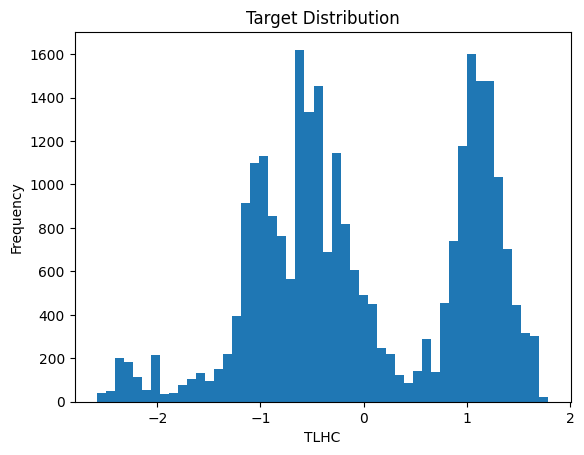

In [158]:

# basicaly frequency distribution of target feature.
import matplotlib.pyplot as plt

plt.figure()
plt.hist(y, bins=50)
plt.xlabel("TLHC")
plt.ylabel("Frequency")
plt.title("Target Distribution")
plt.show()


# CORRELATION HEATMAP

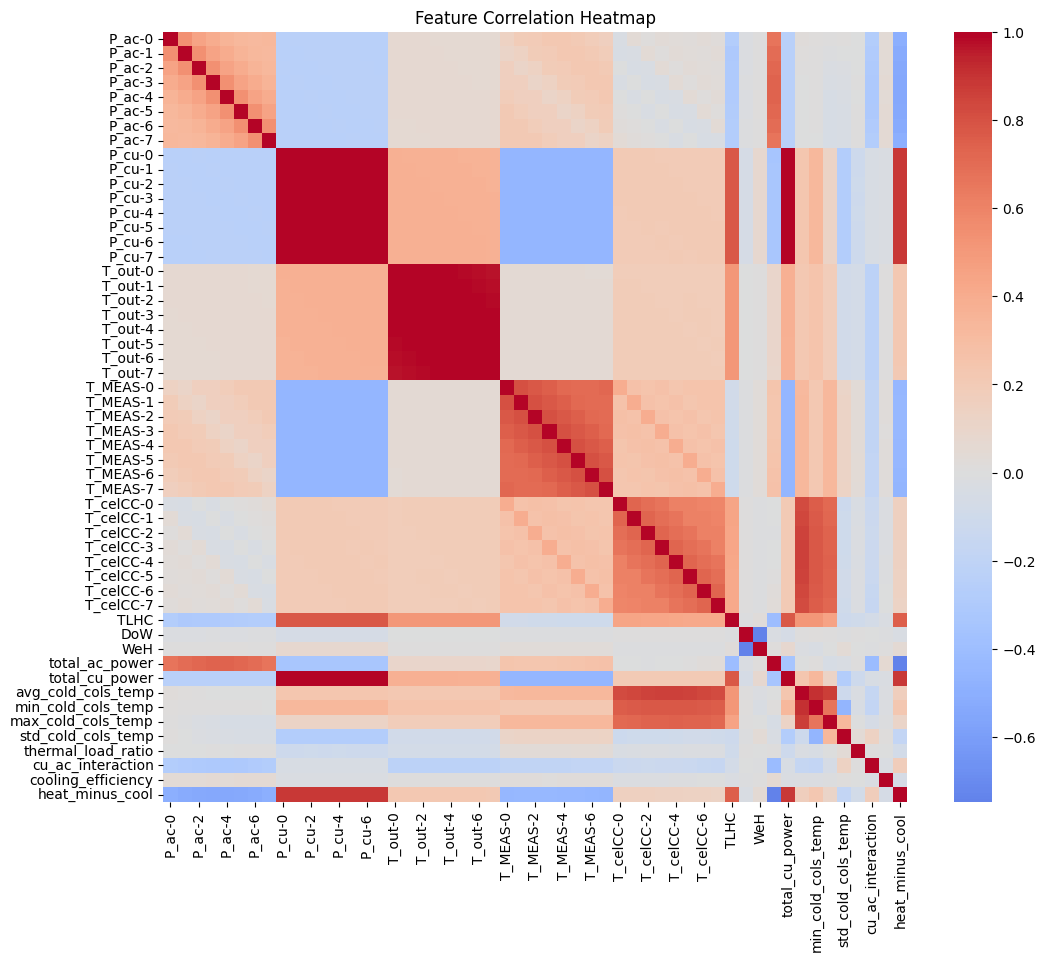

In [159]:

import seaborn as sns

#To understand how variables relate to each other

plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


# FEATURE IMPORTANCE

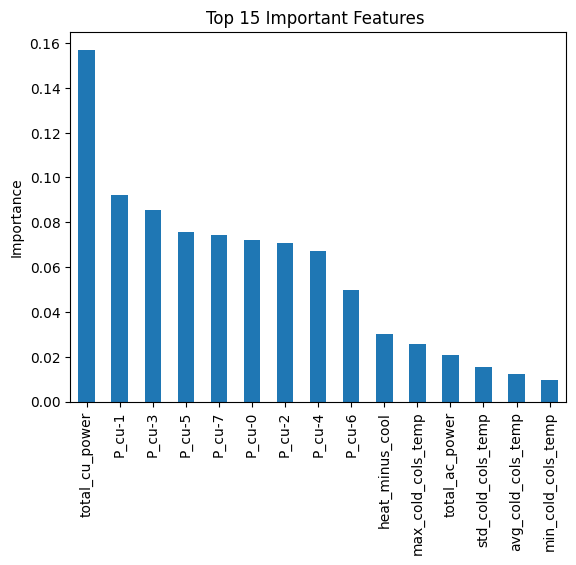

In [160]:

import pandas as pd

#To know what the model thinks is important

importances = pd.Series(
    et_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure()
importances.head(15).plot(kind="bar")
plt.title("Top 15 Important Features ")
plt.ylabel("Importance")
plt.show()


# GENERATE TRAIN + TEST METRICS TABLE

In [161]:

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

#To compare how the model behaves during learning vs real evaluation.

models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gbr_model,
    "Extra Trees": et_model,
    "XGBoost": xgb_model,
    "Ensemble": stack_model
}

results = []

for name, model in models.items():
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    results.append([
        name,
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ])

comparison = pd.DataFrame(
    results,
    columns=["Model", "Train_R2", "Test_R2", "Train_RMSE", "Test_RMSE"]
)

comparison


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE
0,Linear Regression,0.835367,0.834648,4.059264e-01,0.405863
1,Random Forest,0.996064,0.972151,6.276422e-02,0.166563
2,Gradient Boosting,0.943527,0.941280,2.377433e-01,0.241862
3,Extra Trees,1.000000,0.977195,4.051094e-15,0.150728
4,XGBoost,0.986497,0.969206,1.162522e-01,0.175149
5,Ensemble,0.999337,0.977503,2.575375e-02,0.149707


# TRAIN vs TEST R² BAR PLOT


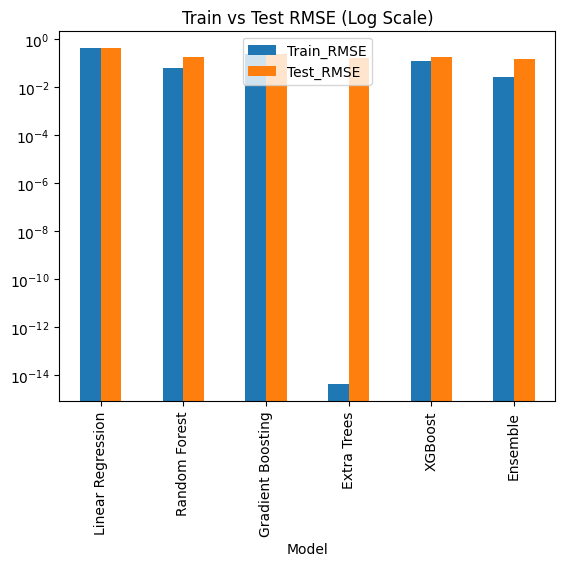

In [162]:

#To visually detect overfitting. If blue bar (train) is much higher than orange (test),the model memorizes too much.
comparison.set_index("Model")[["Train_RMSE","Test_RMSE"]].plot(kind="bar")
plt.yscale("log")
plt.title("Train vs Test RMSE (Log Scale)")
plt.show()


# TRAIN vs TEST RMSE BAR PLOT


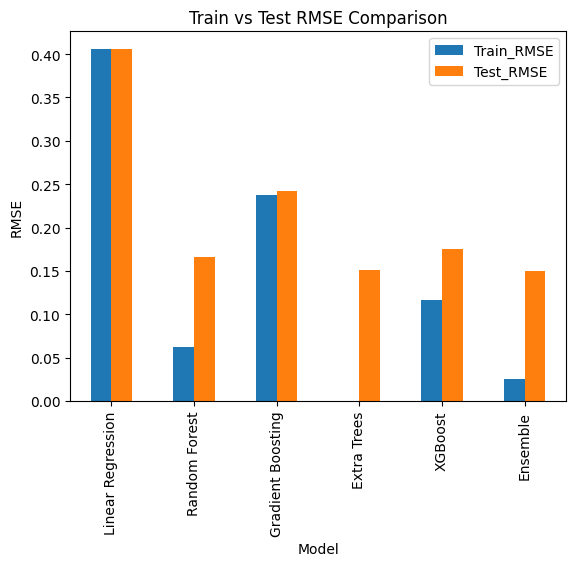

In [163]:
#Same goal as above, but using error instead of accuracy.
comparison.set_index("Model")[["Train_RMSE","Test_RMSE"]].plot(kind="bar")
plt.title("Train vs Test RMSE Comparison")
plt.ylabel("RMSE")
plt.show()


# actual vs predicted of best model


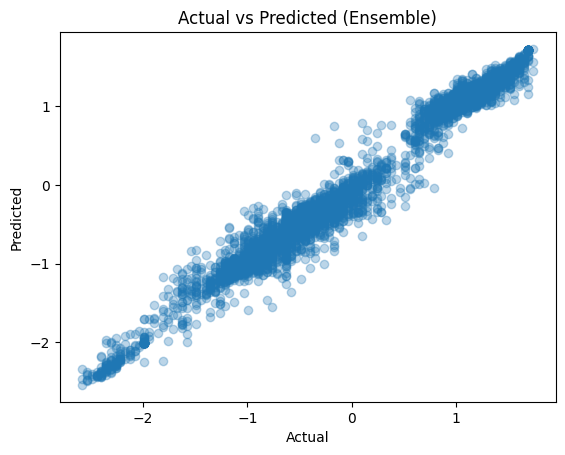

In [164]:
#To see if predictions match reality.
y_pred = stack_model.predict(x_test)

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Ensemble)")
plt.show()


# residual plot


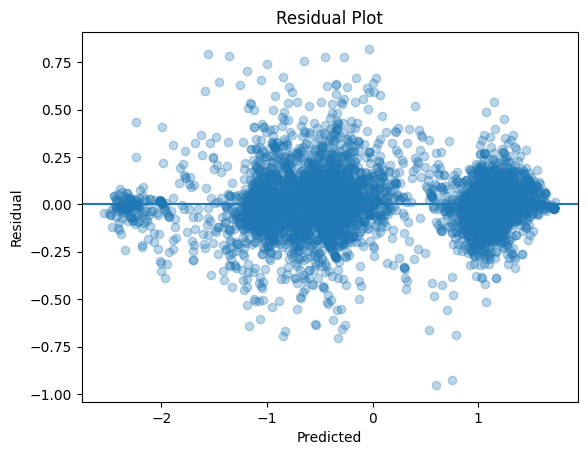

In [165]:
#To check for hidden mistakes. basically it should have scatter points not all in close to 0
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


# residual distribution


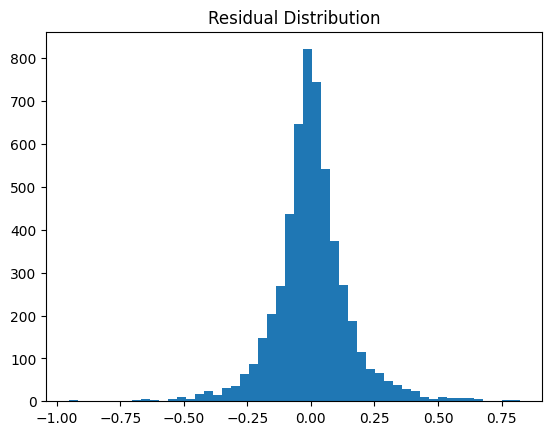

In [166]:
#To see how errors are distributed.A good regression model has: Errors centered around zero
plt.figure()
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()


# ranking model with their accuracy


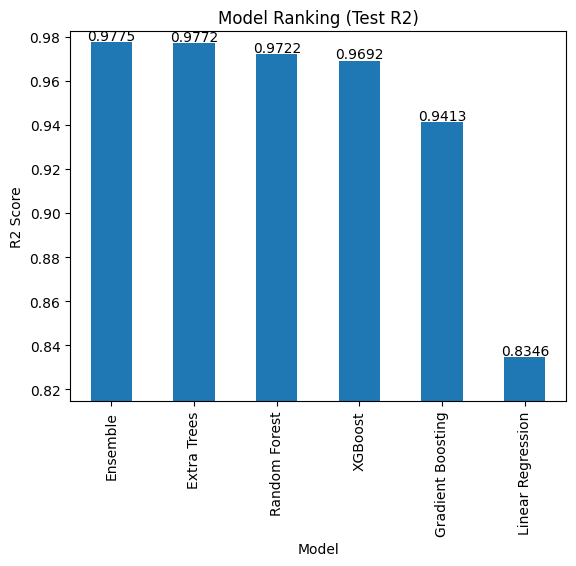

In [167]:
#To clearly compare models
import matplotlib.pyplot as plt

# Sort by performance
comparison_sorted = comparison.sort_values("Test_R2", ascending=False)

plt.figure()

ax = comparison_sorted.set_index("Model")["Test_R2"].plot(kind="bar")

# Zoom slightly below worst model
plt.ylim(comparison_sorted["Test_R2"].min() - 0.02,
         comparison_sorted["Test_R2"].max() + 0.005)

plt.title("Model Ranking (Test R2)")
plt.ylabel("R2 Score")

# Add exact values above bars
for i, v in enumerate(comparison_sorted["Test_R2"]):
    ax.text(i, v + 0.001, f"{v:.4f}", ha='center')

plt.show()


